In [812]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from keras.layers import LSTM, Dense, Dropout, SimpleRNN, GRU
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam


Understanding dataset nature

In [813]:
data = pd.read_csv('AEP_hourly.csv')
data.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [814]:
data.tail()

,Datetime,AEP_MW
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


In [815]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  str    
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), str(1)
memory usage: 1.9 MB


Preparing data for time series forecasting

In [816]:
data['Datetime'] = pd.to_datetime(data['Datetime'])

In [817]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  121273 non-null  datetime64[us]
 1   AEP_MW    121273 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 1.9 MB


In [818]:
data.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [819]:
data.tail()

,Datetime,AEP_MW
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


In [820]:
data.set_index('Datetime', inplace = True)

In [821]:
data.head()

,AEP_MW
Datetime,
2004-12-31 01:00:00,13478.0
2004-12-31 02:00:00,12865.0
2004-12-31 03:00:00,12577.0
2004-12-31 04:00:00,12517.0
2004-12-31 05:00:00,12670.0


EDA

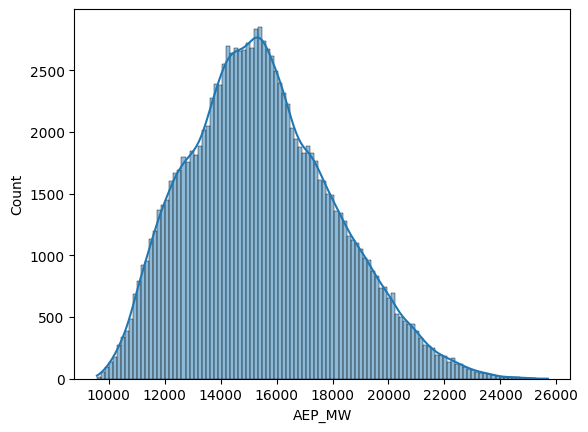

In [822]:
plt.figure()
sns.histplot(data['AEP_MW'], kde = True)
plt.show()

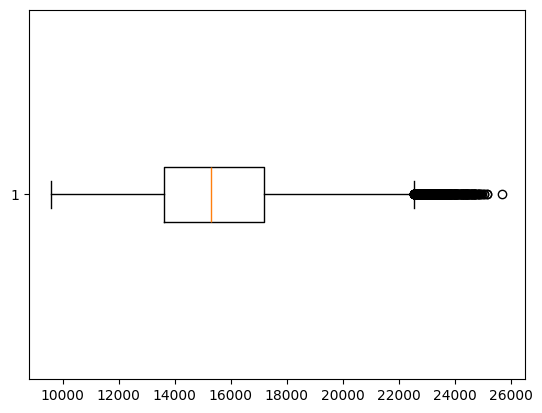

In [823]:
plt.boxplot(data, vert = False)
plt.show()

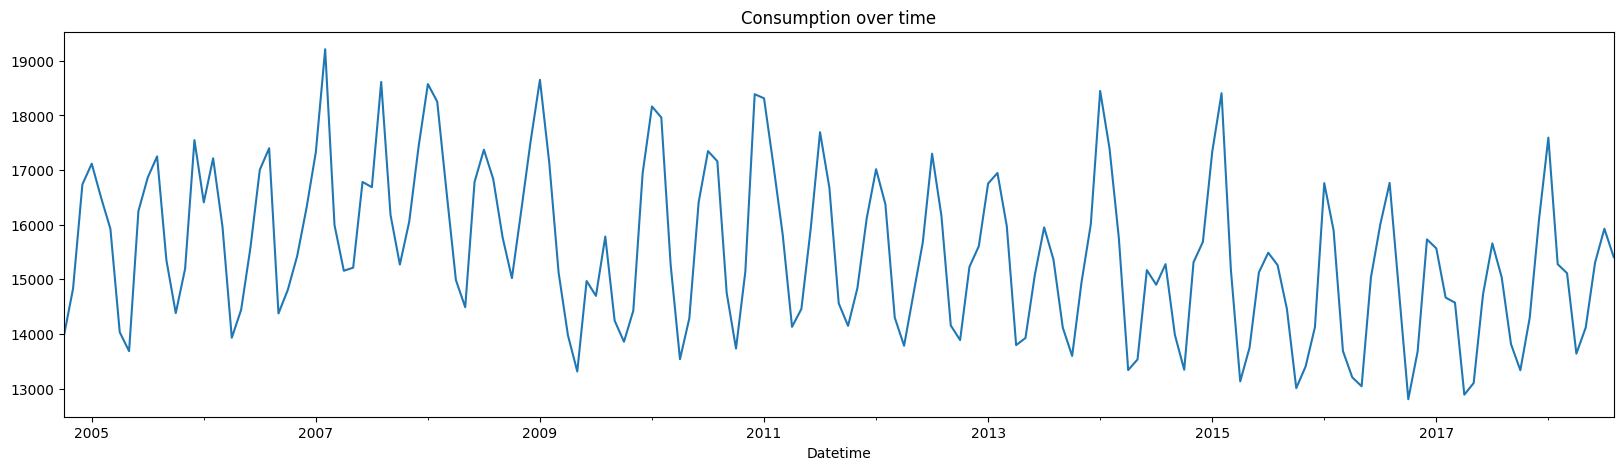

In [824]:
data_2 = data[['AEP_MW']].resample('ME').mean().copy()
data_2['AEP_MW'].plot(title=f"Consumption over time", figsize=(20, 5))
plt.show()

Train test Split

In [825]:
size = int(len(data_2)*0.8)
train_dataset = data_2.iloc[:size].copy()
test_dataset = data_2.iloc[size:].copy()

In [826]:
print(f"p_value: {sts.adfuller(train_dataset['AEP_MW'])[1]}")

p_value: 0.6416605289899769


In [827]:
train_dataset[['AEP_MW']]

,AEP_MW
Datetime,
2004-10-31,13947.537736
2004-11-30,14830.440278
2004-12-31,16737.720430
2005-01-31,17117.088710
2005-02-28,16496.644345
...,...
2015-06-30,15126.598611
2015-07-31,15487.528226
2015-08-31,15260.602151


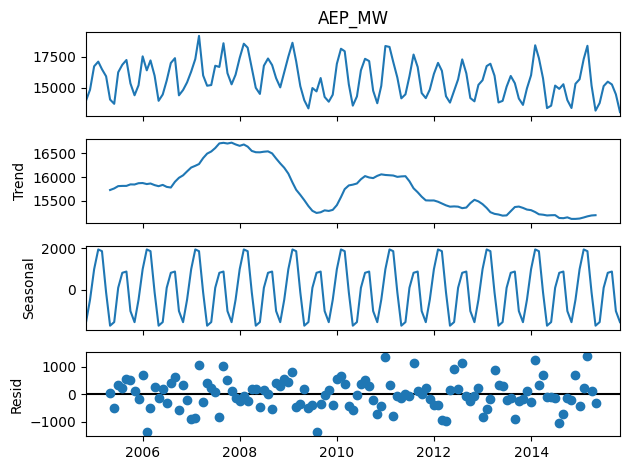

In [828]:
s_dec_additive = seasonal_decompose(train_dataset['AEP_MW'], model='additive')
s_dec_additive.plot()
plt.show()

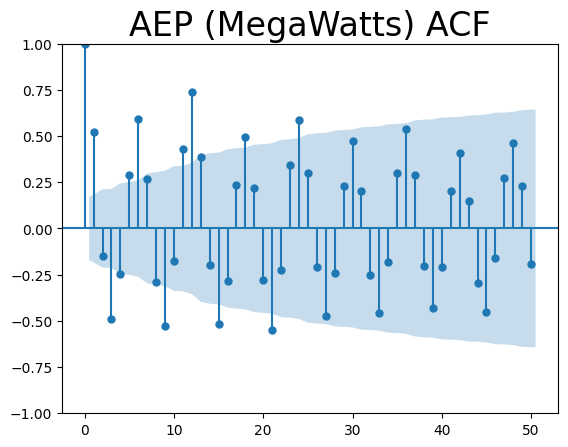

In [829]:
sgt.plot_acf(train_dataset['AEP_MW'], lags=50)
plt.title("AEP (MegaWatts) ACF", size=24)    
plt.show()

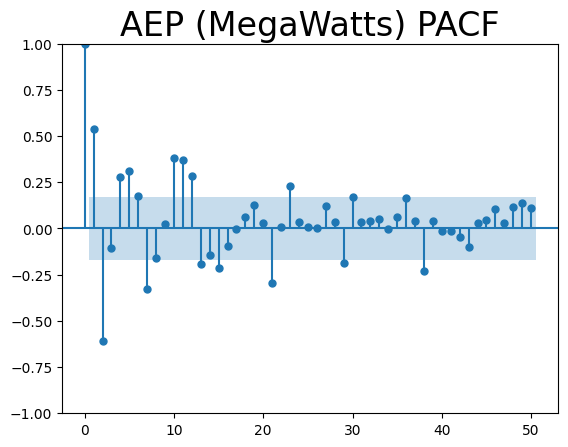

In [830]:
sgt.plot_pacf(train_dataset['AEP_MW'], lags=50, method='ols')
plt.title("AEP (MegaWatts) PACF", size=24)
plt.show()

In [831]:
stationary_data = train_dataset[['AEP_MW']].diff(12).dropna().copy()

In [832]:
stationary_data

,AEP_MW
Datetime,
2005-10-31,433.844498
2005-11-30,364.441667
2005-12-31,810.868280
2006-01-31,-707.252688
2006-02-28,719.383929
...,...
2015-06-30,-41.783333
2015-07-31,585.903226
2015-08-31,-17.698925


In [833]:
print(f"p_value: {sts.adfuller(stationary_data['AEP_MW'])[1]}")

p_value: 0.004762544539967442


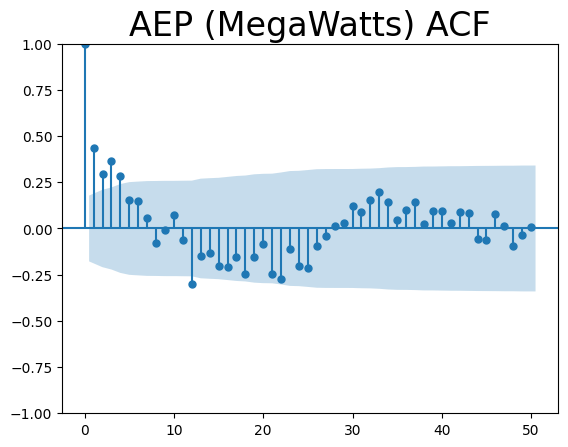

In [834]:
sgt.plot_acf(stationary_data['AEP_MW'], lags=50)
plt.title("AEP (MegaWatts) ACF", size=24)    
plt.show()

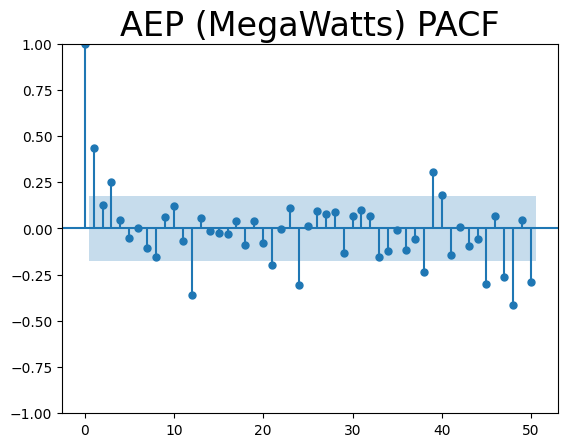

In [835]:
sgt.plot_pacf(stationary_data['AEP_MW'], lags=50, method='ols')
plt.title("AEP (MegaWatts) PACF", size=24)
plt.show()

In [836]:
model_sarima = SARIMAX(train_dataset['AEP_MW'],
                       order=(3, 1, 4),           
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

results_sarima = model_sarima.fit()
print(results_sarima.summary())

                                      SARIMAX Results                                       
Dep. Variable:                               AEP_MW   No. Observations:                  133
Model:             SARIMAX(3, 1, 4)x(1, 1, [1], 12)   Log Likelihood                -815.406
Date:                              Mon, 08 Jun 2026   AIC                           1650.813
Time:                                      12:18:03   BIC                           1677.160
Sample:                                  10-31-2004   HQIC                          1661.484
                                       - 10-31-2015                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2390      0.319      0.750      0.453      -0.386       0.864
ar.L2         -0.74

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [837]:
n_steps = len(test_dataset)
forecast_obj = results_sarima.get_forecast(steps=n_steps)

y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

In [838]:
y_pred_train = results_sarima.fittedvalues

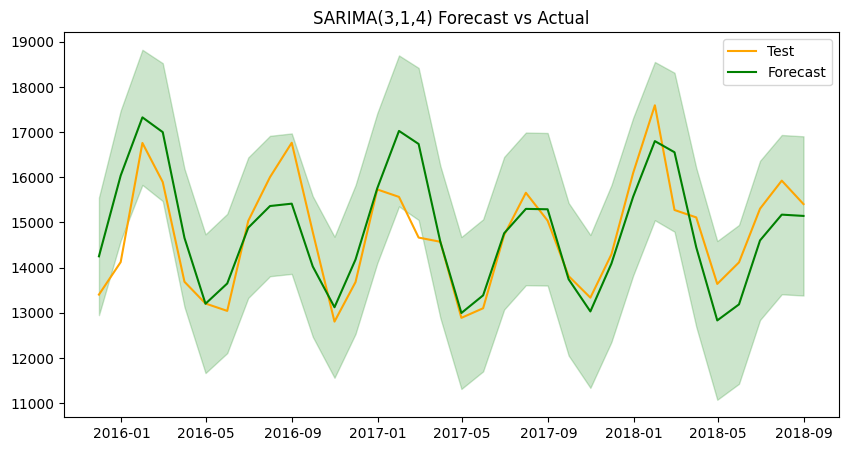

In [839]:
plt.figure(figsize=(10,5))
#plt.plot(train_dataset.index, train_dataset['AEP_MW'], label='Train')
plt.plot(test_dataset.index, test_dataset['AEP_MW'], label='Test', color='orange')
plt.plot(y_pred.index, y_pred, label='Forecast', color='green')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='green', alpha=0.2)
plt.legend()
plt.title('SARIMA(3,1,4) Forecast vs Actual')
plt.show()

In [840]:
mae = mean_absolute_error(test_dataset['AEP_MW'], y_pred)
rmse = np.sqrt(mean_squared_error(test_dataset['AEP_MW'], y_pred))
mae_train = mean_absolute_error(train_dataset['AEP_MW'], y_pred_train)
rmse_train = np.sqrt(mean_squared_error(train_dataset['AEP_MW'], y_pred_train))

print(f"Train MAE : {mae_train:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")

Train MAE : 882.61
Train RMSE: 1801.07
Test MAE : 636.34
Test RMSE: 820.82


In [841]:
mape_train = (abs(train_dataset['AEP_MW'] - y_pred_train) / abs(train_dataset['AEP_MW'])).mean() * 100
mape_test  = (abs(test_dataset['AEP_MW']  - y_pred)  / abs(test_dataset['AEP_MW'])).mean()  * 100
print(f"Train MAPE: {mape_train:.2f}%")
print(f"Test MAPE:  {mape_test:.2f}%")

Train MAPE: 5.67%
Test MAPE:  4.28%


In [842]:
model_arima = ARIMA(train_dataset['AEP_MW'], order=(3,1,4))
results_arima = model_arima.fit()
results_arima.summary()

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 AEP_MW   No. Observations:                  133
Model:                 ARIMA(3, 1, 4)   Log Likelihood               -1087.398
Date:                Mon, 08 Jun 2026   AIC                           2190.797
Time:                        12:18:04   BIC                           2213.859
Sample:                    10-31-2004   HQIC                          2200.168
                         - 10-31-2015                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0214      0.029      0.729      0.466      -0.036       0.079
ar.L2         -0.0113      0.029     -0.390      0.697      -0.068       0.045
ar.L3         -0.9832      0.028    -35.301      0.000      -1.038      -0.929
ma.L1         -0.2451      0.105     -2.337      0.019      -0.451      -0.040
ma.L2          0.0358      0.120      0.298      0.766      -0.200       0.272
ma.L3          0.9461      0.138      6.857      0.000       0.676       1.216
ma.L4         -0.1772      0.067     -2.630      0.009      -0.309      -0.045
sigma2      7.528e+05   2.85e-07   2.65e+12      0.000    7.53e+05    7.53e+05
===================================================================================
Ljung-Box (L1) (Q):                   1.89   Jarque-Bera (JB):                 0.56
Prob(Q):                              0.17   Prob(JB):                         0.75
Heteroskedasticity (H):               0.45   Skew:                             0.10
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.15e+28. Standard errors may be unstable.
"""

In [843]:
n_steps = len(test_dataset)
forecast_obj = results_arima.get_forecast(steps=n_steps)

y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

In [844]:
y_pred_train = results_arima.fittedvalues

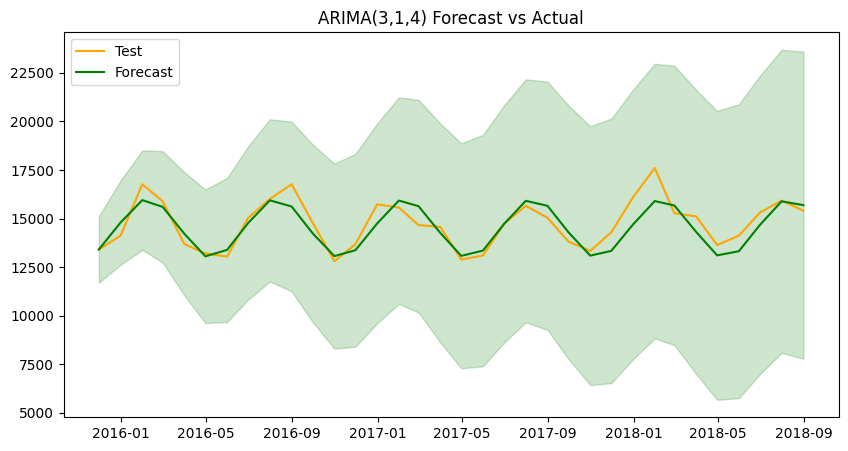

In [845]:
plt.figure(figsize=(10,5))
#plt.plot(train_dataset.index, train_dataset['AEP_MW'], label='Train')
plt.plot(test_dataset.index, test_dataset['AEP_MW'], label='Test', color='orange')
plt.plot(y_pred.index, y_pred, label='Forecast', color='green')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='green', alpha=0.2)
plt.legend()
plt.title('ARIMA(3,1,4) Forecast vs Actual')
plt.show()

In [846]:
mae = mean_absolute_error(test_dataset['AEP_MW'], y_pred)
rmse = np.sqrt(mean_squared_error(test_dataset['AEP_MW'], y_pred))
mae_train = mean_absolute_error(train_dataset['AEP_MW'], y_pred_train)
rmse_train = np.sqrt(mean_squared_error(train_dataset['AEP_MW'], y_pred_train))

print(f"Train MAE : {mae_train:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")

Train MAE : 823.89
Train RMSE: 1525.38
Test MAE : 517.45
Test RMSE: 650.41


Comparing ARIMA and SARIMA Residuals

In [847]:
arima_resid = results_arima.resid
sarima_resid = results_sarima.resid

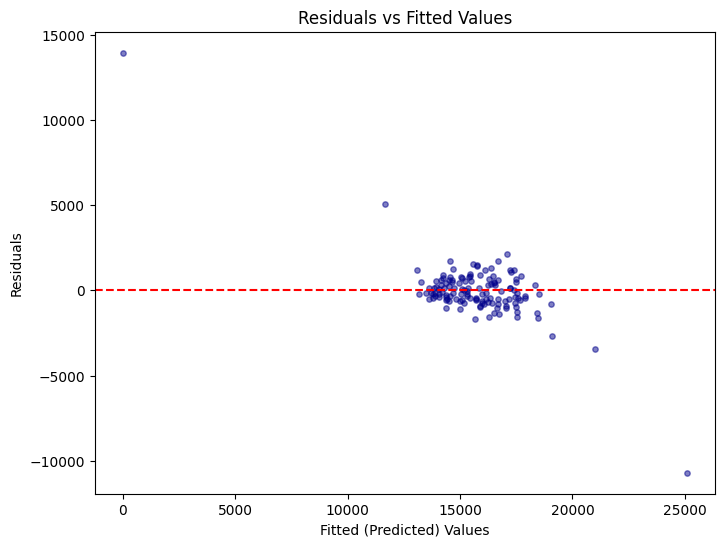

In [848]:
fitted_values = results_sarima.fittedvalues

plt.figure(figsize=(8, 6))
plt.scatter(fitted_values, results_sarima.resid, alpha=0.5, color='darkblue', s=15)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted (Predicted) Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

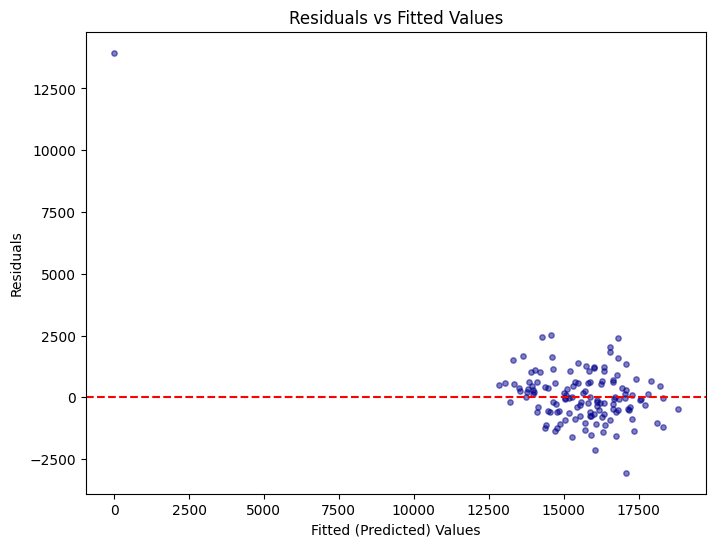

In [849]:
fitted_values = results_arima.fittedvalues

plt.figure(figsize=(8, 6))
plt.scatter(fitted_values, results_arima.resid, alpha=0.5, color='darkblue', s=15)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted (Predicted) Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

In [850]:
train_proph = train_dataset.copy()
train_proph.reset_index(inplace = True)
train_proph.head()

,Datetime,AEP_MW
0,2004-10-31,13947.537736
1,2004-11-30,14830.440278
2,2004-12-31,16737.720430
3,2005-01-31,17117.088710
4,2005-02-28,16496.644345


In [851]:
train_proph = train_proph.rename(columns={'Datetime': 'ds', 'AEP_MW': 'y'})
train_proph.head()

,ds,y
0,2004-10-31,13947.537736
1,2004-11-30,14830.440278
2,2004-12-31,16737.720430
3,2005-01-31,17117.088710
4,2005-02-28,16496.644345


In [852]:
model = Prophet()
model.fit(train_proph)

12:18:04 - cmdstanpy - INFO - Chain [1] start processing
12:18:04 - cmdstanpy - INFO - Chain [1] done processing


In [853]:
test_proph = test_dataset.copy()
test_proph.reset_index(inplace = True)
test_proph.head()

,Datetime,AEP_MW
0,2015-11-30,13403.000000
1,2015-12-31,14123.189516
2,2016-01-31,16760.747312
3,2016-02-29,15895.386494
4,2016-03-31,13687.551817


In [854]:
test_proph = test_proph.rename(columns={'Datetime': 'ds', 'AEP_MW': 'y'})
test_proph.head()

,ds,y
0,2015-11-30,13403.000000
1,2015-12-31,14123.189516
2,2016-01-31,16760.747312
3,2016-02-29,15895.386494
4,2016-03-31,13687.551817


In [855]:
forecast = model.predict(test_proph)

In [856]:
forecast_train = model.predict(train_proph)

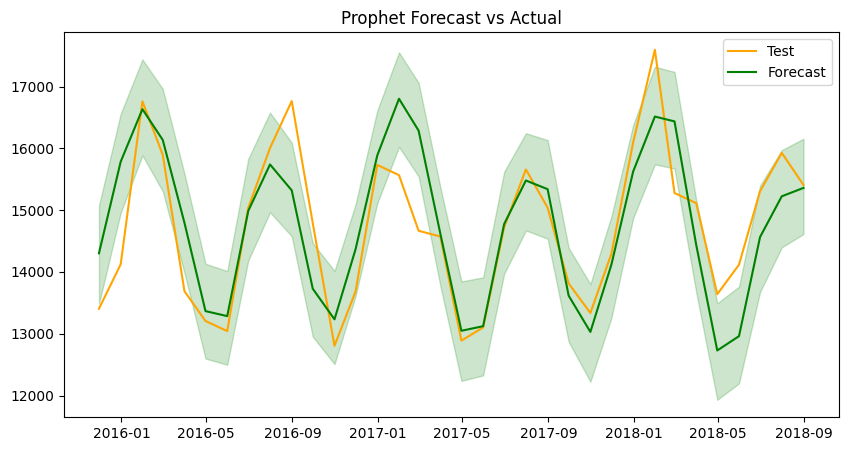

In [857]:
plt.figure(figsize=(10,5))
#plt.plot(train_proph['ds'], train_proph['y'], label='Train')
plt.plot(test_proph['ds'], test_proph['y'], label='Test', color='orange')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='green')
plt.fill_between(forecast['ds'],
                 forecast['yhat_upper'],
                 forecast['yhat_lower'],
                 color='green', alpha=0.2)
plt.legend()
plt.title('Prophet Forecast vs Actual')
plt.show()

In [858]:
mae = mean_absolute_error(test_proph['y'], forecast['yhat'])
rmse = np.sqrt(mean_squared_error(test_proph['y'], forecast['yhat']))
mae_train = mean_absolute_error(train_proph['y'], forecast_train['yhat'])
rmse_train = np.sqrt(mean_squared_error(train_proph['y'], forecast_train['yhat']))

print(f"Train MAE : {mae_train:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Train MAE : 469.87
Train RMSE: 601.00
MAE : 581.13
RMSE: 762.77


In [859]:
data_3 = data_2.copy()
data_3.head()

,AEP_MW
Datetime,
2004-10-31,13947.537736
2004-11-30,14830.440278
2004-12-31,16737.720430
2005-01-31,17117.088710
2005-02-28,16496.644345


In [860]:
#scaler = MinMaxScaler(feature_range=(0, 1))
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_3)

In [861]:
window_size = 12
X = []
y = []
target_dates = data_3.index[window_size:]

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i - window_size:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, target_dates, test_size=0.2, shuffle=False, random_state = 42
)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [862]:
model = Sequential()
model.add(SimpleRNN(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(SimpleRNN(units=128))
model.add(Dropout(0.2))
model.add(Dense(1))

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
custom_learning_rate = 0.001
optimizer = Adam(learning_rate=custom_learning_rate)

model.compile(optimizer=optimizer, loss='mean_squared_error')

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [863]:
history = model.fit(X_train, 
                    y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_split=0.1,
                    callbacks=[early_stop])

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test_1 = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

#rmse = np.sqrt(np.mean((y_test_1 - predictions)**2))
#mae = np.mean(abs(y_test_1 - predictions))
#print(f'RMSE: {rmse:.2f}')
#print(f'MAE: {mae:.2f}')

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 1.2462 - val_loss: 0.3711
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6503 - val_loss: 0.8234
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6239 - val_loss: 0.3630
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5487 - val_loss: 0.4017
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4902 - val_loss: 0.4674
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4288 - val_loss: 0.3462
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4560 - val_loss: 0.2695
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3581 - val_loss: 0.3891
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4042 - val_loss: 0.4010
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3853 - val_loss: 0.2073
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3549 - val_loss: 0.1395
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.3959 - val_lo

In [864]:
predictions_train = model.predict(X_train)
predictions_train = scaler.inverse_transform(predictions_train).flatten()
y_train_1 = scaler.inverse_transform(y_train.reshape(-1,1)).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step  


In [865]:
mae = mean_absolute_error(y_test_1,predictions)
rmse = np.sqrt(mean_squared_error(y_test_1,predictions))
mae_train = mean_absolute_error(y_train_1,predictions_train)
rmse_train = np.sqrt(mean_squared_error(y_train_1,predictions_train))

print(f"Train MAE : {mae_train:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")

Train MAE : 538.22
Train RMSE: 643.65
Test MAE : 676.96
Test RMSE: 802.04


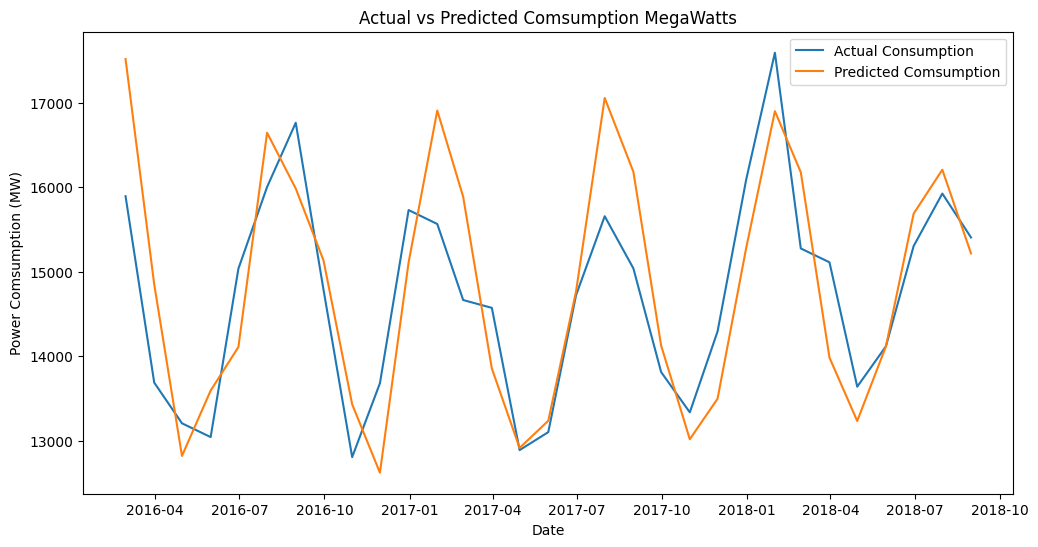

In [866]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_1, label='Actual Consumption')
plt.plot(dates_test, predictions, label='Predicted Comsumption')
plt.title('Actual vs Predicted Comsumption MegaWatts')
plt.xlabel('Date')
plt.ylabel('Power Comsumption (MW)')
plt.legend()
plt.show()

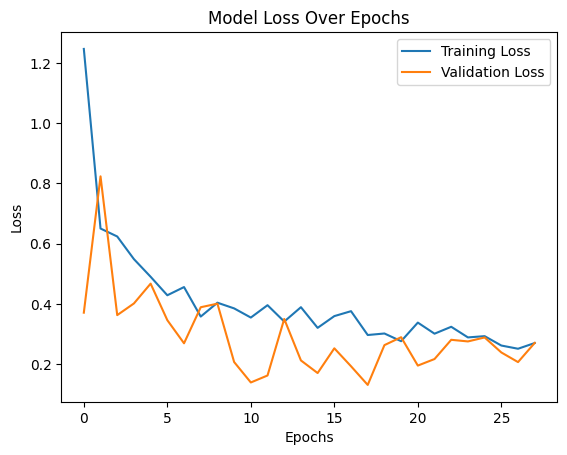

In [867]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [868]:
model = Sequential()
model.add(LSTM(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=128))
model.add(Dropout(0.2))
model.add(Dense(1))

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
custom_learning_rate = 0.001
optimizer = Adam(learning_rate=custom_learning_rate)

model.compile(optimizer=optimizer, loss='mean_squared_error')

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [869]:
history = model.fit(X_train, 
                    y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_split=0.1,
                    callbacks=[early_stop])

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test_1 = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

#rmse = np.sqrt(np.mean((y_test_1 - predictions)**2))
#mae = np.mean(abs(y_test_1 - predictions))
#print(f'RMSE: {rmse:.2f}')
#print(f'MAE: {mae:.2f}')

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.9626 - val_loss: 1.3128
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.9361 - val_loss: 1.2579
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.8951 - val_loss: 1.2142
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.8931 - val_loss: 1.1544
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.8510 - val_loss: 1.1105
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.7894 - val_loss: 1.1076
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.7895 - val_loss: 1.0736
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.7451 - val_loss: 1.0425
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.6646 - val_loss: 1.0973
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.6710 - val_loss: 0.9841
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.6507 - val_loss: 0.9445
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.6558 - val_lo

In [870]:
predictions_train = model.predict(X_train)
predictions_train = scaler.inverse_transform(predictions_train).flatten()
y_train_1 = scaler.inverse_transform(y_train.reshape(-1,1)).flatten()

mae = mean_absolute_error(y_test_1,predictions)
rmse = np.sqrt(mean_squared_error(y_test_1,predictions))
mae_train = mean_absolute_error(y_train_1,predictions_train)
rmse_train = np.sqrt(mean_squared_error(y_train_1,predictions_train))

print(f"Train MAE : {mae_train:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 
Train MAE : 680.90
Train RMSE: 857.80
MAE : 907.85
RMSE: 1128.42


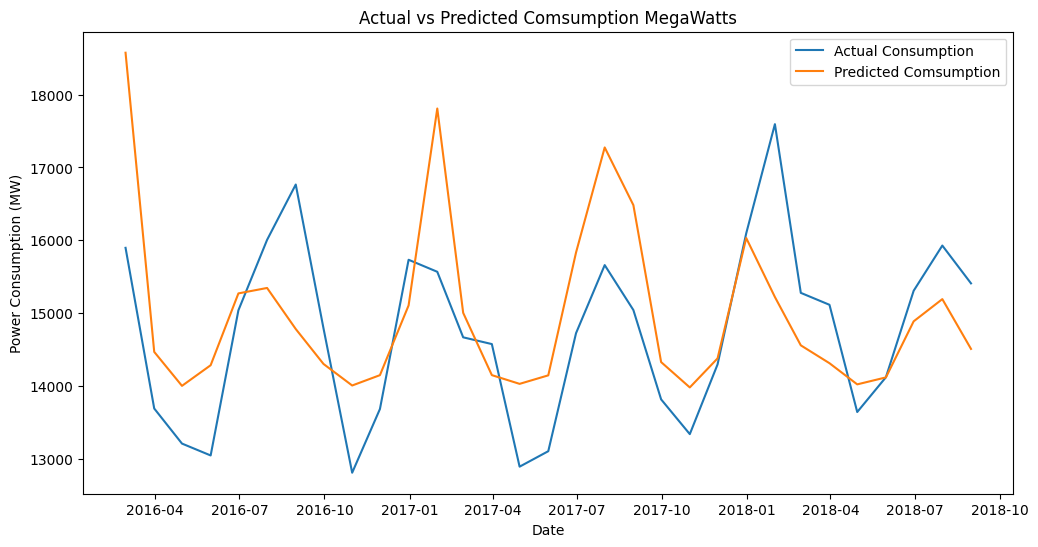

In [871]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_1, label='Actual Consumption')
plt.plot(dates_test, predictions, label='Predicted Comsumption')
plt.title('Actual vs Predicted Comsumption MegaWatts')
plt.xlabel('Date')
plt.ylabel('Power Consumption (MW)')
plt.legend()
plt.show()

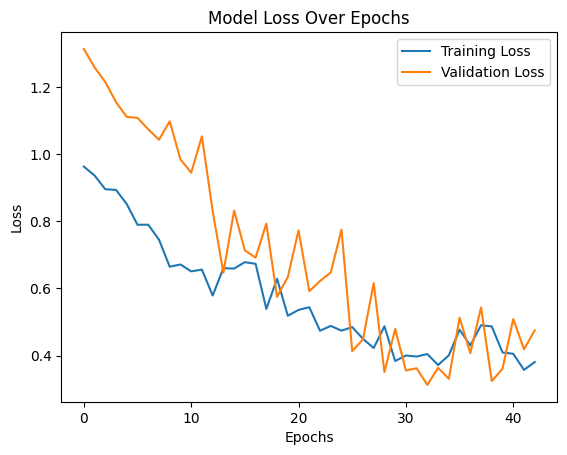

In [872]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [873]:
model = Sequential()
model.add(GRU(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(GRU(units=128))
model.add(Dropout(0.2))
model.add(Dense(1))

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
custom_learning_rate = 0.001
optimizer = Adam(learning_rate=custom_learning_rate)

model.compile(optimizer=optimizer, loss='mean_squared_error')

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [874]:
history = model.fit(X_train, 
                    y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_split=0.1,
                    callbacks=[early_stop])

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test_1 = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

#rmse = np.sqrt(np.mean((y_test_1 - predictions)**2))
#mae = np.mean(abs(y_test_1 - predictions))
#print(f'RMSE: {rmse:.2f}')
#print(f'MAE: {mae:.2f}')

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.9877 - val_loss: 1.3484
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.9405 - val_loss: 1.3332
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.9109 - val_loss: 1.2739
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.8485 - val_loss: 1.1977
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.7783 - val_loss: 1.1197
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.7007 - val_loss: 1.0401
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.6313 - val_loss: 0.9290
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.5421 - val_loss: 0.7987
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.4768 - val_loss: 0.7101
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4421 - val_loss: 0.6578
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.4228 - val_loss: 0.6144
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.4131 - val_l

In [875]:
predictions_train = model.predict(X_train)
predictions_train = scaler.inverse_transform(predictions_train).flatten()
y_train_1 = scaler.inverse_transform(y_train.reshape(-1,1)).flatten()

mae = mean_absolute_error(y_test_1,predictions)
rmse = np.sqrt(mean_squared_error(y_test_1,predictions))
mae_train = mean_absolute_error(y_train_1,predictions_train)
rmse_train = np.sqrt(mean_squared_error(y_train_1,predictions_train))

print(f"Train MAE : {mae_train:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
Train MAE : 504.29
Train RMSE: 643.42
MAE : 532.34
RMSE: 663.72


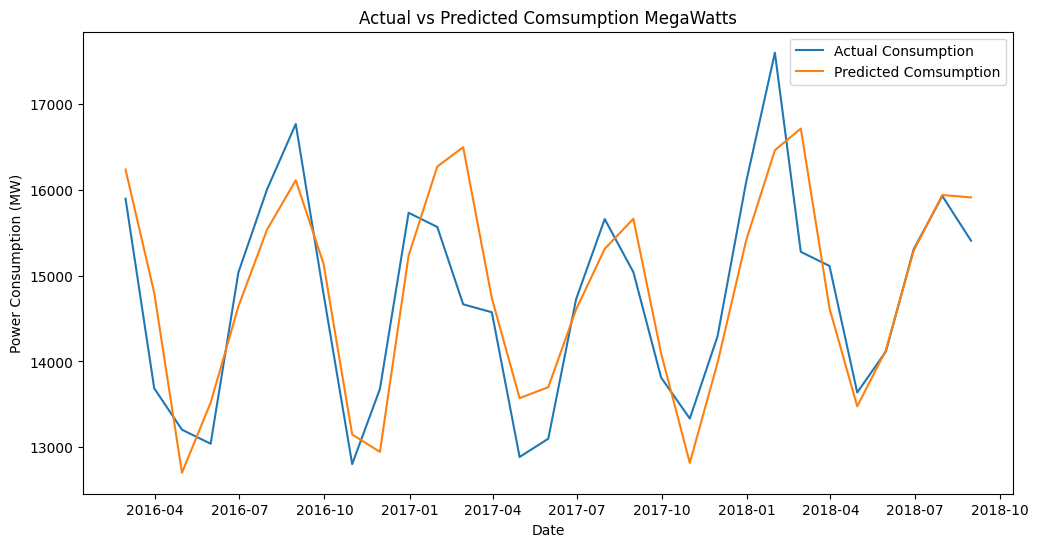

In [876]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_1, label='Actual Consumption')
plt.plot(dates_test, predictions, label='Predicted Comsumption')
plt.title('Actual vs Predicted Comsumption MegaWatts')
plt.xlabel('Date')
plt.ylabel('Power Consumption (MW)')
plt.legend()
plt.show()

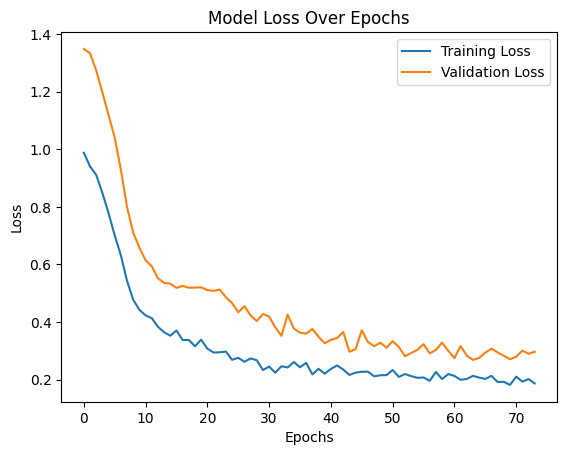

In [877]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Hyperparameter Tune best model (ARIMA)

In [878]:
model = pm.auto_arima(
    train_dataset, 
    start_p=1, start_q=1,
    max_p=5, max_q=5, 
    m=12,              
    seasonal=True,     
    d=None,            
    trace=True,        
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True
)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.54 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2289.954, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2226.074, Time=0.16 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2252.165, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2287.962, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=2284.559, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=2212.252, Time=0.33 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=2204.909, Time=0.64 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=2203.070, Time=0.35 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=2253.250, Time=0.14 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=2204.904, Time=0.79 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=2232.972, Time=0.34 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=2209.316, Time=0.74 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=2203.321, Time=0.32 sec
 ARIMA(2,1,0)(1,0,1)[12]

In [879]:
model_arima_tuned = ARIMA(train_dataset['AEP_MW'], order=(5,1,0), seasonal_order = (1,0,1,12))
results_arima_tuned = model_arima_tuned.fit()
results_arima_tuned.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                             AEP_MW   No. Observations:                  133
Model:             ARIMA(5, 1, 0)x(1, 0, [1], 12)   Log Likelihood               -1085.276
Date:                            Mon, 08 Jun 2026   AIC                           2186.552
Time:                                    12:19:13   BIC                           2209.614
Sample:                                10-31-2004   HQIC                          2195.923
                                     - 10-31-2015                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3077      0.057     -5.368      0.000      -0.420      -0.195
ar.L2         -0.3342      0.044     -7.672      0.000      -0.420      -0.249
ar.L3         -0.3241      0.041     -7.926      0.000      -0.404      -0.244
ar.L4         -0.2933      0.049     -5.974      0.000      -0.389      -0.197
ar.L5         -0.1409      0.063     -2.242      0.025      -0.264      -0.018
ar.S.L12       0.9449      0.057     16.489      0.000       0.833       1.057
ma.S.L12      -0.7588      0.132     -5.765      0.000      -1.017      -0.501
sigma2      5.949e+05   9.03e+04      6.590      0.000    4.18e+05    7.72e+05
===================================================================================
Ljung-Box (L1) (Q):                   1.02   Jarque-Bera (JB):                 4.32
Prob(Q):                              0.31   Prob(JB):                         0.12
Heteroskedasticity (H):               0.45   Skew:                             0.44
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

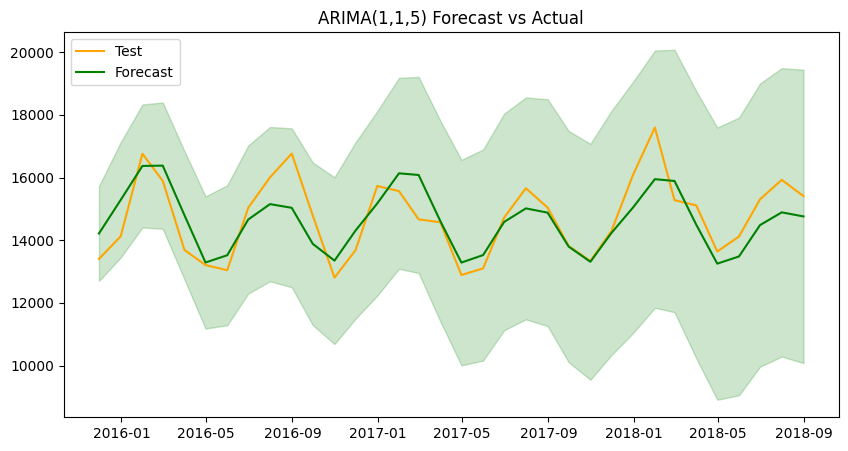

In [880]:
n_steps = len(test_dataset)
forecast_obj = results_arima_tuned.get_forecast(steps=n_steps)

y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

y_pred_train = results_arima_tuned.fittedvalues

plt.figure(figsize=(10,5))
#plt.plot(train_dataset.index, train_dataset['AEP_MW'], label='Train')
plt.plot(test_dataset.index, test_dataset['AEP_MW'], label='Test', color='orange')
plt.plot(y_pred.index, y_pred, label='Forecast', color='green')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='green', alpha=0.2)
plt.legend()
plt.title('ARIMA(1,1,5) Forecast vs Actual')
plt.show()

In [881]:
mae = mean_absolute_error(test_dataset['AEP_MW'], y_pred)
rmse = np.sqrt(mean_squared_error(test_dataset['AEP_MW'], y_pred))
mae_train = mean_absolute_error(train_dataset['AEP_MW'], y_pred_train)
rmse_train = np.sqrt(mean_squared_error(train_dataset['AEP_MW'], y_pred_train))

print(f"Train MAE : {mae_train:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test MAE : {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")

Train MAE : 812.67
Train RMSE: 1521.54
Test MAE : 630.89
Test RMSE: 766.27
